In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load the dataset
data = pd.read_csv("https://raw.githubusercontent.com/bsuryaprakash06/EX-6-NN/refs/heads/main/heart.csv")

# Separate features and target
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardize the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create MLP model
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

# Train the model
mlp.fit(X_train, y_train)

# Make predictions
y_pred = mlp.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Generate classification report
report = classification_report(y_test, y_pred)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

In [12]:
# Display results
print("MLP Heart Disease Prediction")
print("--------------------------------")
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
print("Hidden Layers    : (16, 8)")
print("Activation       : ReLU")

print("\nEvaluation Metrics")
print("--------------------------------")
print("Accuracy  :", round(accuracy * 100, 2), "%")
print("F1-Score  :", round(f1, 4))
print("Recall    :", round(recall, 4))

print("\nClassification Report")
print("--------------------------------")
print(report)

print("Confusion Matrix")
print("--------------------------------")
print(cm)

MLP Heart Disease Prediction
--------------------------------
Training Samples : 820
Testing Samples  : 205
Hidden Layers    : (16, 8)
Activation       : ReLU

Evaluation Metrics
--------------------------------
Accuracy  : 100.0 %
F1-Score  : 1.0
Recall    : 1.0

Classification Report
--------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

Confusion Matrix
--------------------------------
[[100   0]
 [  0 105]]


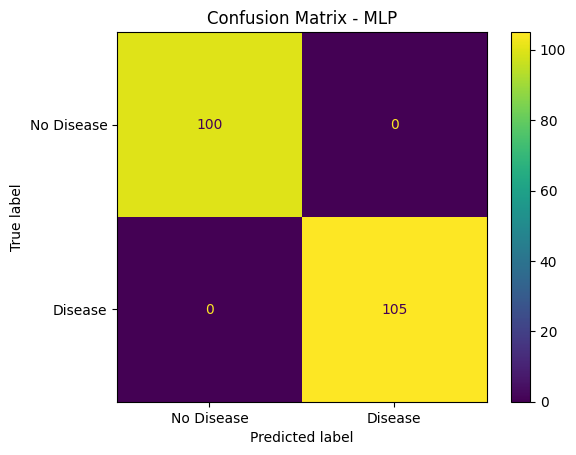

In [13]:
# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()
plt.title("Confusion Matrix - MLP")
plt.show()

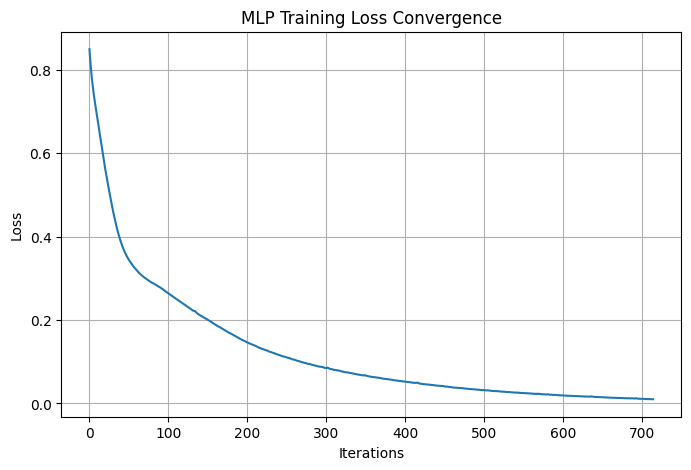

In [14]:
# Plot training loss convergence
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Training Loss Convergence")
plt.grid(True)
plt.show()